<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/05_ARIMA_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5 실습: ARIMA와 Box–Jenkins 절차
**Notebook:** `05_ARIMA_forecasting.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. 비정상 시계열과 차분(Differencing)의 관계를 실제 데이터로 확인합니다.
2. Box–Jenkins 절차의 핵심 단계인 식별(Identification), 추정(Estimation), 진단(Diagnosis), 예측(Forecasting)을 순서대로 실습합니다.
3. ADF 검정과 ACF/PACF를 통해 차분 필요성과 초기 차수 후보를 점검합니다.
4. 여러 ARIMA(<code>p, d, q</code>) 조합을 적합하여 AIC/BIC를 비교합니다.
5. Ljung–Box 검정을 통해 잔차가 백색잡음에 가까운지 확인합니다.
6. 학습/테스트 구간을 나누어 실제 예측 성능을 간단히 평가합니다.

---

## 왜 이 실습이 중요한가?
ARIMA는 비정상 시계열을 다루는 가장 대표적인 고전 모형입니다.  
현실 데이터는 종종 추세를 가지므로, 정상 시계열만을 전제로 하는 ARMA만으로는 직접 모델링하기 어렵습니다.

따라서 이번 실습의 핵심은 단순히 ARIMA 함수를 호출하는 것이 아니라,  
**왜 차분이 필요한지**, **어떻게 차수를 선택하는지**, **잔차 진단을 왜 해야 하는지**를 Box–Jenkins의 흐름 안에서 직접 이해하는 데 있습니다.


In [1]:
# ============================================
# 1. 필수 라이브러리 불러오기
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display


## 1. 온라인 환경 준비
이번 실습은 Google Colab 또는 Jupyter Notebook에서 바로 실행할 수 있도록 구성했습니다.

실제 금융 시계열 예시를 위해 `yfinance`를 사용합니다.  
설치되어 있지 않다면 자동으로 설치합니다.


In [2]:
# ============================================
# 2. yfinance 설치 및 임포트
# ============================================

try:
    import yfinance as yf
    print("yfinance가 이미 설치되어 있습니다.")
except ImportError:
    print("yfinance가 설치되어 있지 않아 지금 설치합니다...")
    !pip -q install yfinance
    import yfinance as yf
    print("yfinance 설치가 완료되었습니다.")


yfinance가 이미 설치되어 있습니다.


## 2. 시각화 기본 설정
이번 버전도 Colab 호환성을 위해 **그래프 텍스트는 영어**로 출력합니다.  
마크다운 셀과 코드 주석은 한글로 유지합니다.


In [3]:
# ============================================
# 3. 시각화 기본 설정
# ============================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False


## 3. 시계열 분석 도구 불러오기
이번 실습에서는 다음 도구를 사용합니다.

- `adfuller`: 단위근 검정(ADF)
- `plot_acf`, `plot_pacf`: 자기상관 구조 시각화
- `ARIMA`: ARIMA 모형 적합
- `acorr_ljungbox`: 잔차 자기상관 진단


In [4]:
# ============================================
# 4. 시계열 분석 함수 불러오기
# ============================================

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox


## 4. 실제 금융 데이터 불러오기
이번 실습에서는 **애플(AAPL)** 의 일별 종가를 예시로 사용합니다.

ARIMA는 비정상 시계열에도 적용할 수 있지만,  
그 핵심은 <code>d</code> 차수만큼 차분하여 안정적인 구조를 만드는 데 있습니다.

> 주의  
> `yfinance` 결과는 환경에 따라 **MultiIndex columns**가 될 수 있습니다.  
> 따라서 `Close` 컬럼 접근 시 올바른 튜플 순서를 사용해야 합니다.


In [5]:
# ============================================
# 5. 애플(AAPL) 데이터 다운로드
# ============================================

ticker = "AAPL"
start_date = "2018-01-01"
end_date = "2024-12-31"

df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

print(f"Ticker: {ticker}")
print(f"Shape: {df.shape}")
display(df.head())


Ticker: AAPL
Shape: (1760, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2018-01-02,40.304173,43.064999,43.075001,42.314999,42.540001,102223600
2018-01-03,40.297169,43.057499,43.637501,42.990002,43.132500,118071600
2018-01-04,40.484341,43.257500,43.367500,43.020000,43.134998,89738400
2018-01-05,40.945271,43.750000,43.842499,43.262501,43.360001,94640000
2018-01-08,40.793171,43.587502,43.902500,43.482498,43.587502,82271200


## 5. MultiIndex 컬럼을 고려한 종가 추출
`yfinance`는 경우에 따라 컬럼이 다음처럼 MultiIndex가 될 수 있습니다.

- <code>('Close', 'AAPL')</code>
- <code>('Open', 'AAPL')</code>
- ...

따라서 안전하게 종가 시리즈를 꺼내는 helper 함수를 만들겠습니다.


In [6]:
# ============================================
# 6. 종가 시리즈를 안전하게 추출하는 함수
# ============================================

def get_close_series(df, ticker):
    # MultiIndex columns인 경우
    if isinstance(df.columns, pd.MultiIndex):
        return df[("Close", ticker)].copy()
    # 단일 컬럼 구조인 경우
    return df["Close"].copy()

close_series = get_close_series(df, ticker)
close_series.name = "Close"

display(close_series.head())


,Close
Date,
2018-01-02,43.064999
2018-01-03,43.057499
2018-01-04,43.257500
2018-01-05,43.750000
2018-01-08,43.587502


## 6. 기초 시각화: 가격 수준 확인
먼저 가격 수준(level) 자체를 그려보겠습니다.

관찰 포인트는 다음과 같습니다.

- 장기 추세가 존재하는가?
- 특정 구간에 급락/급등이 있는가?
- 평균이 일정해 보이는가, 아니면 이동하는가?

ARIMA에서는 이런 비정상성의 존재를 먼저 의심하는 것이 중요합니다.


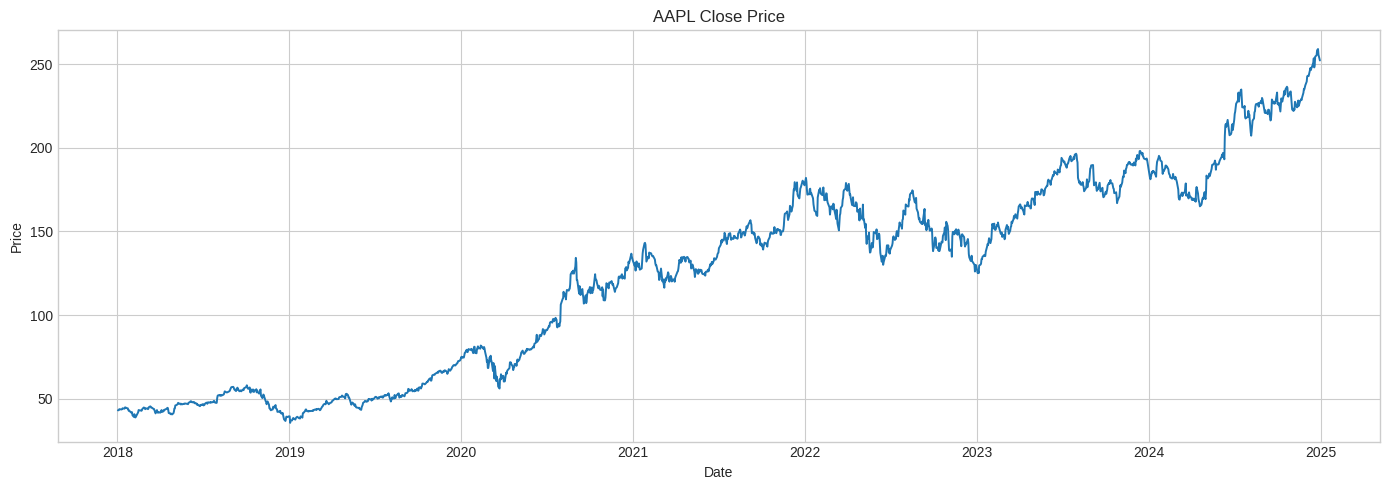

In [7]:
# ============================================
# 7. 가격 수준 플롯
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(close_series.index, close_series, linewidth=1.4)

plt.title("AAPL Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


## 7. ADF 검정 함수 만들기
ADF 검정은 비정상성 여부를 점검하는 대표적인 도구입니다.

- 귀무가설: 단위근이 존재한다 (비정상)
- p-value가 충분히 작으면 귀무가설을 기각 → 정상성에 더 가까움


In [8]:
# ============================================
# 8. ADF 검정 보고 함수
# ============================================

def adf_report(series, name="Series"):
    series = pd.Series(series).dropna()
    result = adfuller(series, autolag="AIC")
    print(f"===== {name} =====")
    print("ADF Statistic :", round(result[0], 4))
    print("ADF p-value   :", round(result[1], 4))
    print("-" * 40)


In [9]:
# ============================================
# 9. 가격 수준의 ADF 검정
# ============================================

# 사용자가 수정한 MultiIndex 안전 접근 패턴도 함께 반영
if isinstance(df.columns, pd.MultiIndex):
    adf_report(df[('Close', 'AAPL')].dropna(), "AAPL Close Price")
else:
    adf_report(df["Close"].dropna(), "AAPL Close Price")


===== AAPL Close Price =====
ADF Statistic : 0.0263
ADF p-value   : 0.9607
----------------------------------------


## 8. 1차 차분과 2차 차분 만들기
ARIMA의 <code>d</code>는 차분 횟수를 의미합니다.

- 1차 차분: <code>y_t - y_(t-1)</code>
- 2차 차분: 1차 차분을 다시 차분한 값

실무에서는 보통 <code>d = 0, 1, 2</code> 범위에서 탐색하는 경우가 많습니다.


In [10]:
# ============================================
# 10. 1차 차분과 2차 차분 생성
# ============================================

diff1 = close_series.diff()
diff2 = diff1.diff()

display(pd.DataFrame({
    "Close": close_series.head(10),
    "Diff1": diff1.head(10),
    "Diff2": diff2.head(10)
}))


,Close,Diff1,Diff2
Date,,,
2018-01-02,43.064999,NaN,NaN
2018-01-03,43.057499,-0.007500,NaN
2018-01-04,43.257500,0.200001,0.207500
2018-01-05,43.750000,0.492500,0.292500
2018-01-08,43.587502,-0.162498,-0.654999
2018-01-09,43.582500,-0.005001,0.157497
2018-01-10,43.572498,-0.010002,-0.005001
2018-01-11,43.820000,0.247501,0.257504
2018-01-12,44.272499,0.452499,0.204998


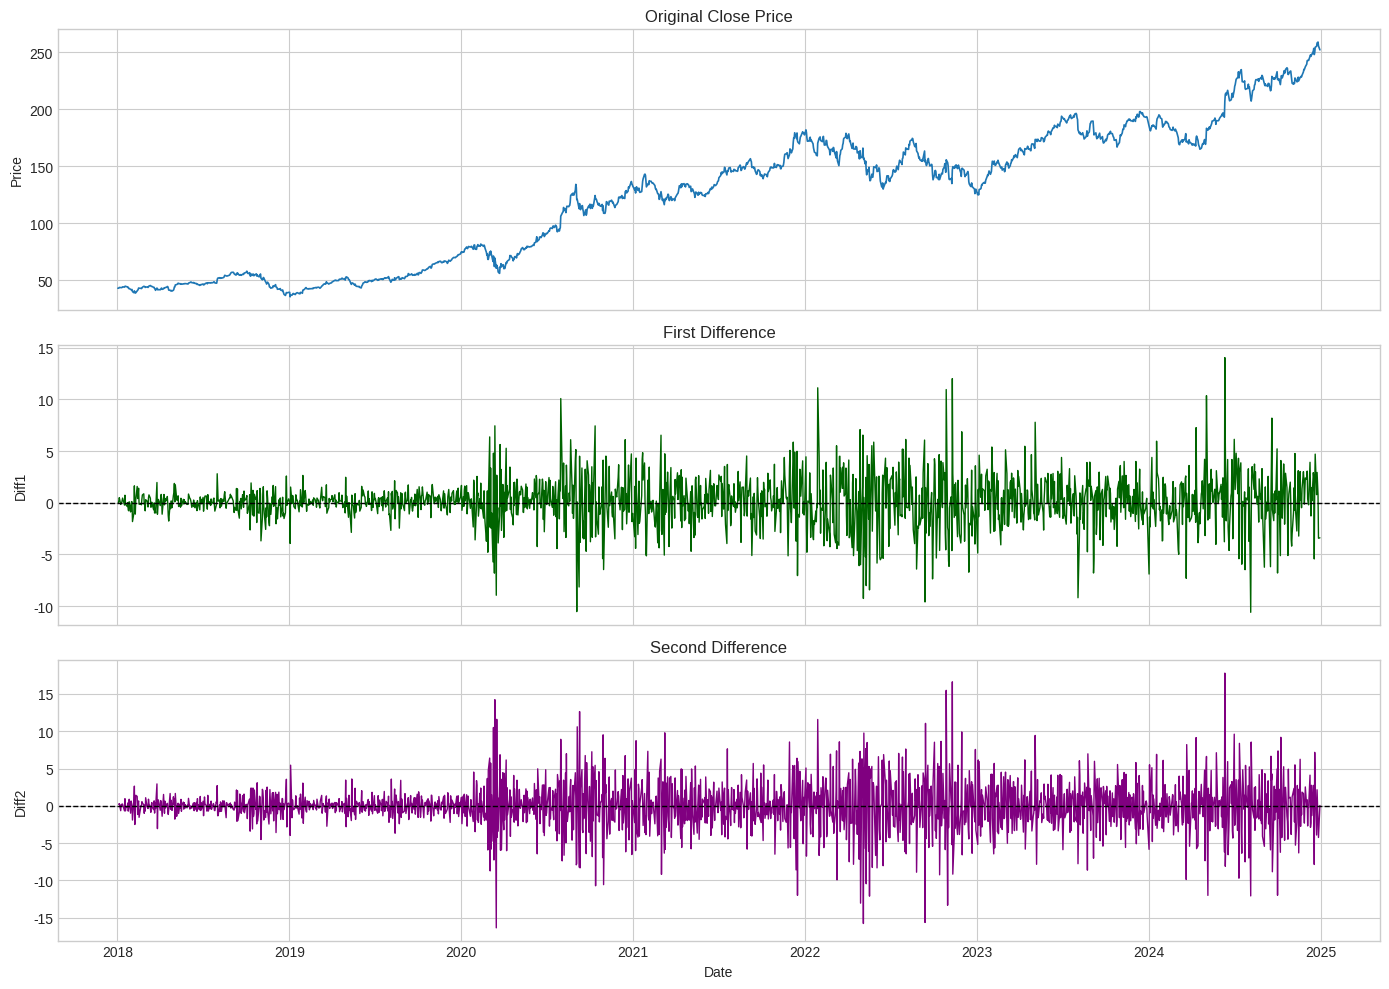

In [11]:
# ============================================
# 11. 원시 시계열과 차분 시계열 비교
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(close_series.index, close_series, linewidth=1.2)
axes[0].set_title("Original Close Price")
axes[0].set_ylabel("Price")

axes[1].plot(diff1.index, diff1, linewidth=1.0, color="darkgreen")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("First Difference")
axes[1].set_ylabel("Diff1")

axes[2].plot(diff2.index, diff2, linewidth=1.0, color="purple")
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Second Difference")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Diff2")

plt.tight_layout()
plt.show()


In [12]:
# ============================================
# 12. 차분 후 ADF 검정
# ============================================

adf_report(diff1.dropna(), "First Difference")
adf_report(diff2.dropna(), "Second Difference")


===== First Difference =====
ADF Statistic : -42.5502
ADF p-value   : 0.0
----------------------------------------
===== Second Difference =====
ADF Statistic : -14.0809
ADF p-value   : 0.0
----------------------------------------


## 9. ACF / PACF로 초기 차수 후보 보기
Box–Jenkins의 식별 단계에서는 ACF/PACF를 함께 봅니다.

실제 ARIMA 식별에서는  
1. 먼저 차분 차수 <code>d</code>를 정하고  
2. 차분된 시계열에 대해 <code>p</code>, <code>q</code> 후보를 생각합니다.

여기서는 1차 차분 시계열을 기준으로 초기 후보를 살펴보겠습니다.


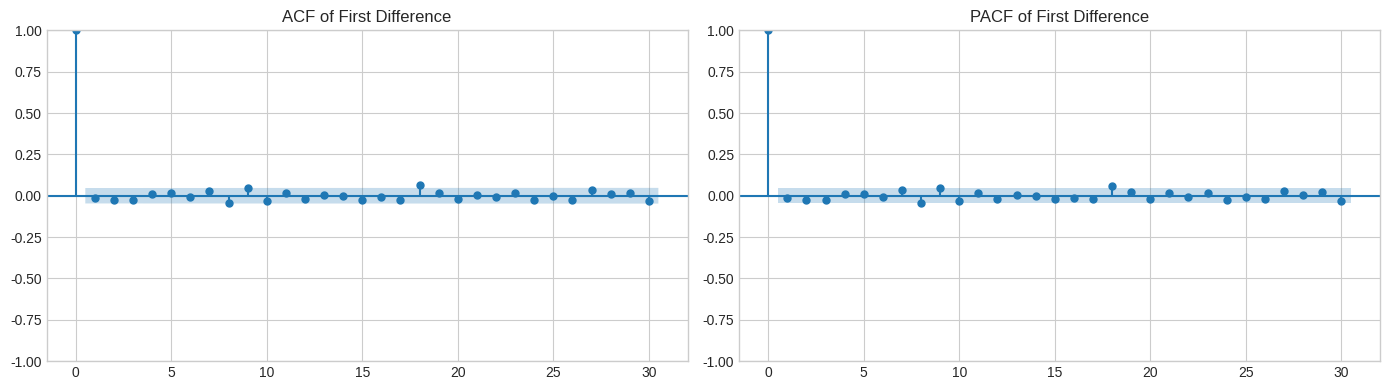

In [13]:
# ============================================
# 13. 1차 차분 시계열의 ACF / PACF
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff1.dropna(), lags=30, ax=axes[0])
plot_pacf(diff1.dropna(), lags=30, ax=axes[1], method="ywm")

axes[0].set_title("ACF of First Difference")
axes[1].set_title("PACF of First Difference")

plt.tight_layout()
plt.show()


## 10. 학습/테스트 구간 나누기
예측 성능을 확인하려면 데이터를 학습용(train)과 테스트용(test)으로 나누어야 합니다.  
시계열에서는 무작위 분할이 아니라 **시간 순서대로** 나누어야 합니다.

여기서는 전체 데이터의 마지막 20%를 테스트 구간으로 둡니다.


In [14]:
# ============================================
# 14. Train / Test split
# ============================================

split_idx = int(len(close_series) * 0.8)

train = close_series.iloc[:split_idx]
test = close_series.iloc[split_idx:]

print("Train length:", len(train))
print("Test length :", len(test))


Train length: 1408
Test length : 352


## 11. 단순 그리드 탐색으로 ARIMA(<code>p,d,q</code>) 비교
이번 실습에서는 <code>p, d, q</code>를 작은 범위에서 바꾸어가며 AIC/BIC를 비교합니다.

탐색 범위:
- <code>p = 0,1,2,3</code>
- <code>d = 0,1,2</code>
- <code>q = 0,1,2,3</code>

이 방식은 `auto_arima`와 같은 자동화 함수의 핵심 아이디어를 이해하는 데 도움이 됩니다.


In [15]:
# ============================================
# 15. ARIMA 그리드 탐색
# ============================================

results_list = []

for p in range(4):
    for d in range(3):
        for q in range(4):
            try:
                fitted = ARIMA(train, order=(p, d, q)).fit()
                results_list.append({
                    "p": p,
                    "d": d,
                    "q": q,
                    "AIC": fitted.aic,
                    "BIC": fitted.bic
                })
            except Exception:
                pass

grid_df = pd.DataFrame(results_list).sort_values("AIC").reset_index(drop=True)
display(grid_df.head(15))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,p,d,q,AIC,BIC
0,2,2,3,6227.692317,6259.183341
1,3,2,3,6229.303037,6266.042566
2,3,0,2,6240.941479,6277.690958
3,1,1,3,6241.258061,6267.504137
4,2,1,3,6241.616839,6273.112129
5,1,2,3,6242.164101,6268.406621
6,0,1,1,6242.170045,6252.668476
7,2,2,2,6242.192784,6268.435304
8,1,1,0,6242.324850,6252.823280
9,3,1,2,6242.606525,6274.101815


## 12. 최적 모형 선택 및 적합
이제 AIC가 가장 낮은 조합을 선택하여 최종 학습 모형을 적합합니다.

실제 연구에서는 AIC만이 아니라
- BIC
- 해석 가능성
- 잔차 진단
- 예측 성능

을 함께 고려해야 합니다.


In [16]:
# ============================================
# 16. 최적 ARIMA 모형 선택
# ============================================

best_p = int(grid_df.loc[0, "p"])
best_d = int(grid_df.loc[0, "d"])
best_q = int(grid_df.loc[0, "q"])

print(f"Best order by AIC: ({best_p}, {best_d}, {best_q})")

best_model = ARIMA(train, order=(best_p, best_d, best_q)).fit()
print(best_model.summary())


Best order by AIC: (2, 2, 3)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1408
Model:                 ARIMA(2, 2, 3)   Log Likelihood               -3107.846
Date:                Sun, 15 Mar 2026   AIC                           6227.692
Time:                        01:35:23   BIC                           6259.183
Sample:                             0   HQIC                          6239.462
                               - 1408                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.8561      0.012   -156.598      0.000      -1.879      -1.833
ar.L2         -0.9748      0.012    -83.255      0.000      -0.998      -0.952
ma.L1          0.8423      0.049     17.305      0.0

## 13. 잔차 진단
ARIMA 모형이 적절하다면, 잔차는 추가적인 자기상관 구조를 많이 남기지 않아야 합니다.

여기서는 다음을 점검합니다.

1. 잔차 시계열 플롯
2. 잔차의 ACF
3. Ljung–Box 검정


In [17]:
# ============================================
# 17. 잔차 추출
# ============================================

resid = best_model.resid
display(resid.head())


,0
Date,
2018-01-02,43.064999
2018-01-03,-21.539994
2018-01-04,0.207271
2018-01-05,0.400977
2018-01-08,-0.382227


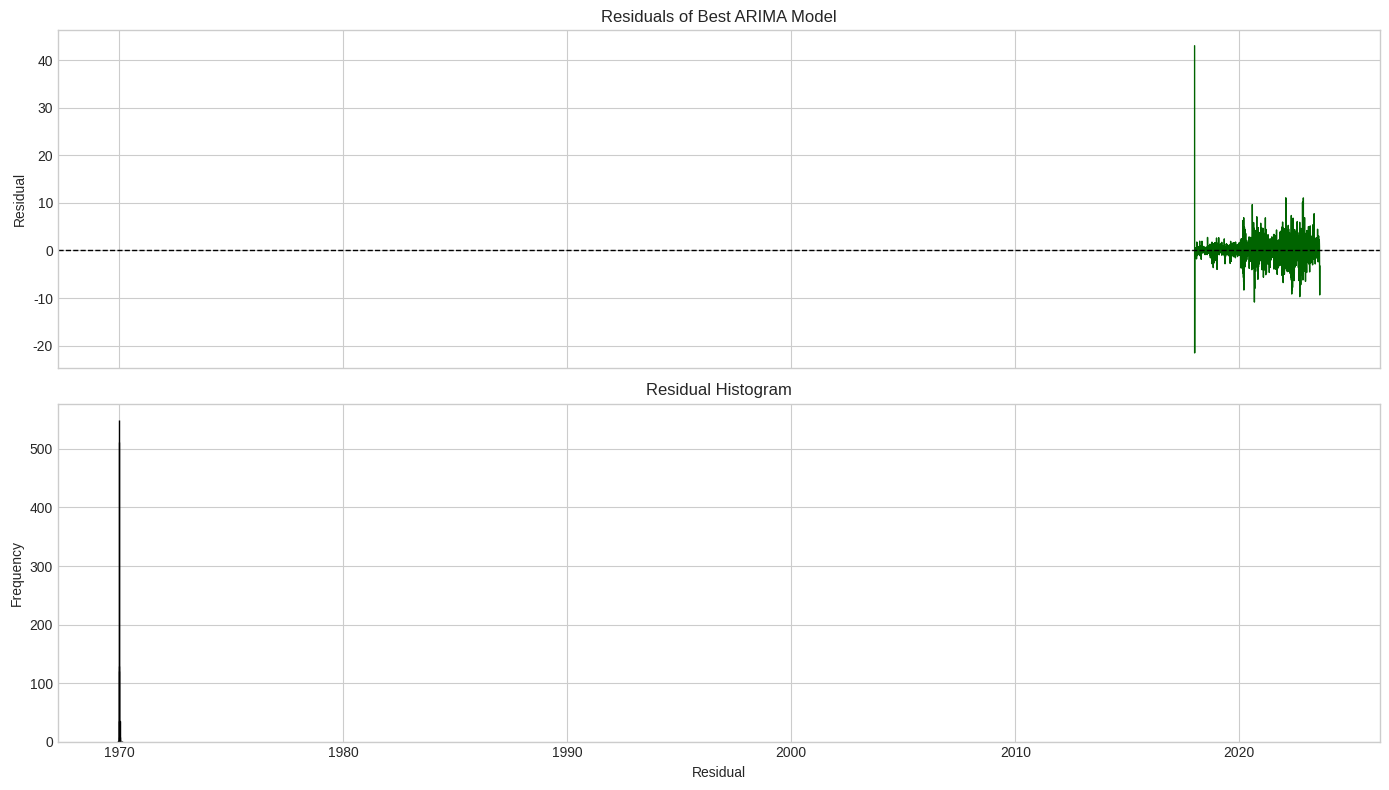

In [18]:
# ============================================
# 18. 잔차 시각화
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(resid, color="darkgreen", linewidth=1)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Residuals of Best ARIMA Model")
axes[0].set_ylabel("Residual")

axes[1].hist(resid.dropna(), bins=30, edgecolor="black")
axes[1].set_title("Residual Histogram")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


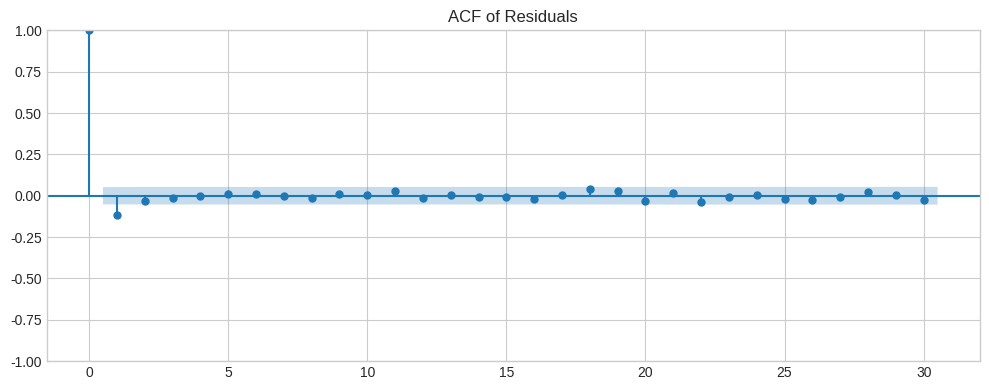

In [19]:
# ============================================
# 19. 잔차의 ACF
# ============================================

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resid.dropna(), lags=30, ax=ax)
ax.set_title("ACF of Residuals")

plt.tight_layout()
plt.show()


In [20]:
# ============================================
# 20. Ljung-Box 검정
# ============================================
# 귀무가설: 잔차에 자기상관이 없다
# p-value가 충분히 크면 잔차가 백색잡음에 더 가까움
# ============================================

lb_df = acorr_ljungbox(resid.dropna(), lags=[10, 20], return_df=True)
display(lb_df)


,lb_stat,lb_pvalue
10,20.992793,0.021144
20,27.747324,0.115517


## 14. 테스트 구간 예측
이제 학습된 ARIMA 모형으로 테스트 구간을 예측합니다.

관찰 포인트는 다음과 같습니다.

- 예측선이 실제 흐름을 얼마나 따라가는가?
- 추세 방향을 대략 반영하는가?
- 예측구간(confidence interval)은 얼마나 넓은가?


In [21]:
# ============================================
# 21. 테스트 구간 예측
# ============================================

forecast_result = best_model.get_forecast(steps=len(test))
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

display(pd.DataFrame({
    "Actual": test.head(),
    "Forecast": forecast_mean.head()
}))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,Actual,Forecast
2023-08-08 00:00:00,179.800003,NaN
2023-08-09 00:00:00,178.190002,NaN
2023-08-10 00:00:00,177.970001,NaN
2023-08-11 00:00:00,177.789993,NaN
2023-08-14 00:00:00,179.460007,NaN
1408,NaN,179.164045
1409,NaN,178.937086
1410,NaN,179.422024
1411,NaN,179.113029
1412,NaN,179.583631


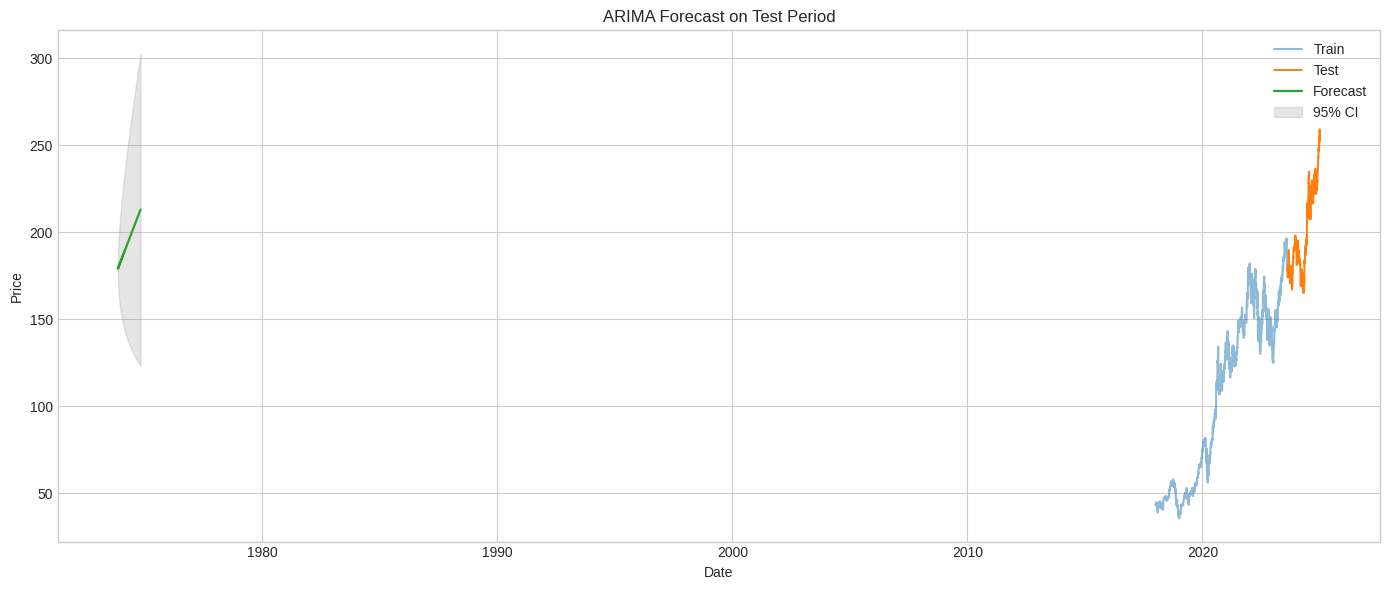

In [22]:
# ============================================
# 22. 실제값과 예측값 비교
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Train", alpha=0.5)
plt.plot(test.index, test, label="Test", linewidth=1.4)
plt.plot(forecast_mean.index, forecast_mean, label="Forecast", linewidth=1.6)

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color="gray",
    alpha=0.2,
    label="95% CI"
)

plt.title("ARIMA Forecast on Test Period")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


## 15. 예측 오차 평가
이번 실습에서는 가장 기본적인 오차 지표 두 가지를 계산합니다.

- **MAE**: 평균 절대 오차
- **RMSE**: 평균 제곱근 오차

가격 수준 예측에서는 값의 크기가 크기 때문에, 절대적 수치 해석과 함께 그래프를 같이 보는 것이 중요합니다.


In [23]:
# ============================================
# 23. 예측 오차 계산
# ============================================

mae = np.mean(np.abs(test - forecast_mean))
rmse = np.sqrt(np.mean((test - forecast_mean) ** 2))

print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))


MAE : nan
RMSE: nan


## 16. 차분 차수와 예측의 관계 다시 생각하기
ARIMA에서 <code>d</code>는 단순한 하이퍼파라미터가 아니라,  
시계열이 얼마나 강한 비정상성을 가지는지를 반영하는 중요한 구조적 선택입니다.

- <code>d = 0</code>: 이미 정상에 가까운 시계열
- <code>d = 1</code>: 보통의 추세 제거
- <code>d = 2</code>: 더 강한 비정상성 제거

하지만 과도한 차분(over-differencing)은 원래 구조를 훼손할 수 있으므로 항상 주의해야 합니다.


In [24]:
# ============================================
# 24. 상위 후보 모형 비교
# ============================================

display(grid_df.head(10))


,p,d,q,AIC,BIC
0,2,2,3,6227.692317,6259.183341
1,3,2,3,6229.303037,6266.042566
2,3,0,2,6240.941479,6277.690958
3,1,1,3,6241.258061,6267.504137
4,2,1,3,6241.616839,6273.112129
5,1,2,3,6242.164101,6268.406621
6,0,1,1,6242.170045,6252.668476
7,2,2,2,6242.192784,6268.435304
8,1,1,0,6242.324850,6252.823280
9,3,1,2,6242.606525,6274.101815


## 17. 실습 정리
이번 실습에서 확인한 핵심은 다음과 같습니다.

- ARIMA는 비정상 시계열을 차분하여 모델링하는 고전적 방법이다.
- Box–Jenkins 절차는 식별, 추정, 진단, 예측의 흐름으로 이해할 수 있다.
- ADF 검정과 차분은 비정상성 문제를 다루는 출발점이다.
- ACF/PACF는 초기 차수 후보를 생각하는 데 유용하다.
- 실제 차수 선택은 AIC/BIC 같은 정보 기준과 함께 해야 한다.
- 최종 모형은 잔차가 백색잡음에 가까운지 반드시 점검해야 한다.
- 예측 성능은 train/test 분할을 통해 별도로 확인해야 한다.


## 18. 연습문제 (Exercises)

1. 애플(AAPL) 대신 마이크로소프트(MSFT) 또는 테슬라(TSLA) 데이터를 사용하여 같은 ARIMA 그리드 탐색을 수행하시오.

2. 1차 차분 대신 2차 차분을 기준으로 ACF/PACF를 본 뒤, 차수 후보가 어떻게 달라지는지 비교하시오.

3. AIC 기준 최적 모형과 BIC 기준 최적 모형이 다를 경우, 왜 그런 차이가 생길 수 있는지 설명하시오.

4. Ljung–Box 검정의 귀무가설이 무엇인지 서술하고, p-value가 작을 때 어떤 해석을 해야 하는지 설명하시오.

5. 가격 수준 대신 로그 수익률에 ARIMA를 적합했을 때 결과가 어떻게 달라지는지 비교해 보시오.
